# Задание №10. Создание модели для прогнозирования спортивных результатов (нейросетевая классификация исходов матчей)


**Выполнил:** Асламин В.В.


**Группа:** МОм-24-1


**Дата:** 2026


**Ссылка на репозиторий:** https://github.com/mystic-solis/deep-learning

---

## 1. Введение


**Цель работы:** построить и обучить полносвязную нейронную сеть для прогнозирования исходов спортивных матчей (футбол) – многоклассовая классификация: победа хозяев, ничья, победа гостей.


**Задачи:**
- Подготовить синтетический датасет с признаками матчей
- Выполнить кодирование категориальных признаков и масштабирование числовых
- Построить полносвязную нейронную сеть (MLP)
- Обучить модель с фиксацией времени обучения
- Оценить качество модели с помощью метрик
- Реализовать функцию предсказания исхода новых матчей
- Сохранить модель и вспомогательные объекты
- Загрузить модель из репозитория и выполнить инференс

## 2. Теоретическая часть

### 2.1. Задача прогнозирования спортивных исходов

Цель – предсказать результат спортивного события (победа хозяев, ничья, победа гостей). Это сложная задача из-за множества влияющих факторов: форма команд, травмы игроков, статистика личных встреч, погодные условия, мотивация и др.

### 2.2. Признаки (features) и целевая переменная

Признаки могут быть:
- **Статистические**: среднее количество голов, процент побед, количество ударов по воротам
- **Контекстные**: место проведения (дома/в гостях), текущая позиция в турнирной таблице
- **Внешние**: погода, судья, травмы ключевых игроков

Целевая переменная – исход матча (0 – победа гостей, 1 – ничья, 2 – победа хозяев).

### 2.3. Предобработка и масштабирование

Числовые признаки часто имеют разные масштабы (например, возраст, количество голов). Для нейронных сетей их необходимо нормализовать (StandardScaler или MinMaxScaler). Категориальные признаки (например, название команды) кодируются с помощью LabelEncoder или OneHotEncoder.

### 2.4. Полносвязная нейронная сеть (MLP)

В отличие от текстовых задач, здесь используется полносвязная нейронная сеть (MLP), состоящая из нескольких плотных слоёв (Dense) с активациями ReLU и выходным слоем с softmax (для многоклассовой классификации). Такие сети способны выявлять нелинейные зависимости между признаками.

### 2.5. Метрики качества

- **Accuracy** – доля правильных предсказаний
- **Precision / Recall / F1-score** – особенно важны при дисбалансе классов
- **ROC‑AUC** – оценивает способность модели разделять классы

### 2.6. Фиксация времени обучения

Для оценки производительности и воспроизводимости эксперимента необходимо фиксировать время, затраченное на обучение модели. В коде используется модуль `time`.

## 3. Описание данных

### 3.1. Источник данных

В данной работе используется синтетический датасет `sports_data.csv`, содержащий признаки и целевую переменную исхода матча.

In [1]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping
import pickle
import requests
import io
from pathlib import Path

print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


In [26]:
import pandas as pd
import numpy as np
import random

data_path = Path('./data/')
dataset = data_path / 'sports_data.csv'

if not dataset.exists():
    np.random.seed(42)
    n_matches = 2000

    teams = ['Team_A', 'Team_B', 'Team_C', 'Team_D', 'Team_E', 'Team_F']
    data = []

    for _ in range(n_matches):
        home = random.choice(teams)
        away = random.choice([t for t in teams if t != home])
        # Признаки: средние голы за последние 5 матчей
        home_goals_avg = np.random.uniform(0.5, 2.5)
        away_goals_avg = np.random.uniform(0.5, 2.5)
        home_wins_pct = np.random.uniform(0.2, 0.8)
        away_wins_pct = np.random.uniform(0.2, 0.8)
        # Вероятность исхода (логистическая функция)
        prob_home = 1 / (1 + np.exp(-(home_goals_avg - away_goals_avg + 0.2*(home_wins_pct - away_wins_pct))))
        prob_away = 1 / (1 + np.exp(-(away_goals_avg - home_goals_avg + 0.2*(away_wins_pct - home_wins_pct))))
        prob_draw = 1 - prob_home - prob_away
        prob_draw = max(0.1, prob_draw)
        prob_home = prob_home * (1 - prob_draw)
        prob_away = prob_away * (1 - prob_draw)
        prob_home, prob_away, prob_draw = prob_home/(prob_home+prob_away+prob_draw), prob_away/(prob_home+prob_away+prob_draw), prob_draw/(prob_home+prob_away+prob_draw)
        outcome = np.random.choice([0,1,2], p=[prob_away, prob_draw, prob_home])  # 0=гости, 1=ничья, 2=хозяева
        data.append([home, away, home_goals_avg, away_goals_avg, home_wins_pct, away_wins_pct, outcome])
    df = pd.DataFrame(data, columns=['team_home', 'team_away', 'home_goals_avg', 'away_goals_avg', 'home_wins_pct', 'away_wins_pct', 'outcome'])
    data_path.mkdir(exist_ok=True)
    df.to_csv(data_path/'sports_data.csv', index=False)
else:
    df = pd.read_csv(dataset)

print("Данные загружены из репозитория")
print(f"Загружено матчей: {len(df)}")
print("\nПервые 5 строк:")
df.head()

Данные загружены из репозитория
Загружено матчей: 2000

Первые 5 строк:


,team_home,team_away,home_goals_avg,away_goals_avg,home_wins_pct,away_wins_pct,outcome
0,Team39,Team29,0.96,2.45,0.66,0.57,0
1,Team23,Team11,1.65,1.33,0.39,0.69,1
2,Team2,Team25,2.58,1.03,0.41,0.41,2
3,Team12,Team23,0.52,0.56,0.61,0.54,1
4,Team28,Team16,1.08,0.73,0.67,0.53,2


### 3.2. Статистика данных

In [27]:
# Статистика по данным
print("=" * 50)
print("СТАТИСТИКА ДАННЫХ")
print("=" * 50)

# Описание признаков
print("\nОписание признаков:")
print(df.describe())

# Распределение классов
print("\nРаспределение исходов матчей:")
outcome_counts = df['outcome'].value_counts().sort_index()
print(outcome_counts)

outcome_map = {0: 'Победа гостей', 1: 'Ничья', 2: 'Победа хозяев'}
print("\nПроцентное распределение:")
for idx, count in outcome_counts.items():
    print(f"  {outcome_map[idx]}: {count/len(df)*100:.1f}%")

СТАТИСТИКА ДАННЫХ

Описание признаков:
       home_goals_avg  away_goals_avg  home_wins_pct  away_wins_pct  \
count     2000.000000     2000.000000    2000.000000    2000.000000   
mean         1.755085        1.756735       0.600310       0.598820   
std          0.718250        0.724269       0.173293       0.174417   
min          0.500000        0.500000       0.300000       0.300000   
25%          1.140000        1.130000       0.450000       0.450000   
50%          1.760000        1.760000       0.600000       0.600000   
75%          2.380000        2.390000       0.750000       0.750000   
max          3.000000        3.000000       0.900000       0.900000   

           outcome  
count  2000.000000  
mean      0.997000  
std       0.894087  
min       0.000000  
25%       0.000000  
50%       1.000000  
75%       2.000000  
max       2.000000  

Распределение исходов матчей:
outcome
0    802
1    402
2    796
Name: count, dtype: int64

Процентное распределение:
  Победа гост

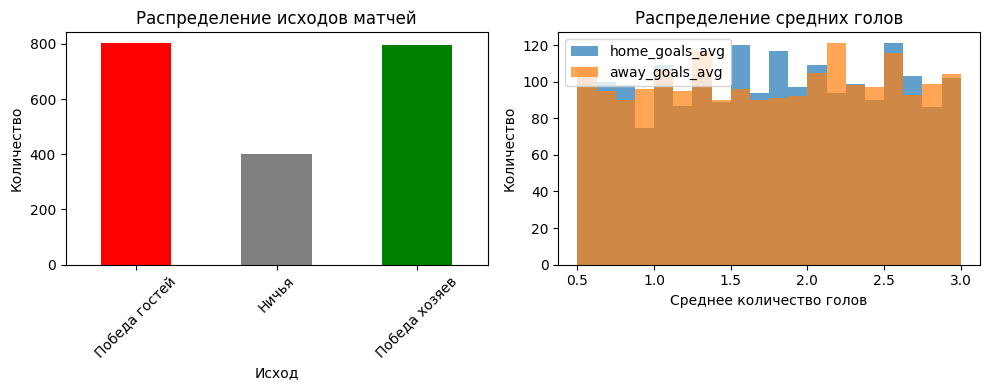

In [28]:
# Визуализация распределения классов
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
outcome_counts.plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Распределение исходов матчей')
plt.xlabel('Исход')
plt.ylabel('Количество')
plt.xticks(range(3), ['Победа гостей', 'Ничья', 'Победа хозяев'], rotation=45)

plt.subplot(1, 2, 2)
plt.hist(df['home_goals_avg'], bins=20, alpha=0.7, label='home_goals_avg')
plt.hist(df['away_goals_avg'], bins=20, alpha=0.7, label='away_goals_avg')
plt.title('Распределение средних голов')
plt.xlabel('Среднее количество голов')
plt.ylabel('Количество')
plt.legend()

plt.tight_layout()
plt.show()

## 4. Подготовка данных

In [29]:
# Кодирование категориальных признаков (названия команд)
le_home = LabelEncoder()
le_away = LabelEncoder()
df['team_home_enc'] = le_home.fit_transform(df['team_home'])
df['team_away_enc'] = le_away.fit_transform(df['team_away'])

# Выбираем числовые признаки и закодированные команды
feature_cols = ['team_home_enc', 'team_away_enc', 'home_goals_avg', 'away_goals_avg', 'home_wins_pct', 'away_wins_pct']
X = df[feature_cols].values
y = df['outcome'].values  # 0, 1, 2

print(f"Признаки: {feature_cols}")
print(f"Форма X: {X.shape}")
print(f"Форма y: {y.shape}")
print(f"\nУникальные команды (home): {len(le_home.classes_)}")
print(f"Уникальные команды (away): {len(le_away.classes_)}")

Признаки: ['team_home_enc', 'team_away_enc', 'home_goals_avg', 'away_goals_avg', 'home_wins_pct', 'away_wins_pct']
Форма X: (2000, 6)
Форма y: (2000,)

Уникальные команды (home): 50
Уникальные команды (away): 50


In [30]:
# Масштабируем только числовые признаки (кроме закодированных команд)
scaler = StandardScaler()
# Индексы числовых колонок: 2, 3, 4, 5
X[:, 2:] = scaler.fit_transform(X[:, 2:])

print("Масштабирование выполнено")
print(f"Среднее (после масштабирования): {X[:, 2:].mean(axis=0).round(4)}")
print(f"Стандартное отклонение (после масштабирования): {X[:, 2:].std(axis=0).round(4)}")

Масштабирование выполнено
Среднее (после масштабирования): [-0. -0.  0.  0.]
Стандартное отклонение (после масштабирования): [1. 1. 1. 1.]


In [31]:
# Разделение на обучающую и тестовую выборки (80/20) со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающих примеров: {len(X_train)}")
print(f"Тестовых примеров: {len(X_test)}")

print("\nРаспределение классов в обучающей выборке:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  {outcome_map[cls]}: {cnt}")

Обучающих примеров: 1600
Тестовых примеров: 400

Распределение классов в обучающей выборке:
  Победа гостей: 641
  Ничья: 322
  Победа хозяев: 637


## 5. Построение модели

In [33]:
# Построение полносвязной нейронной сети (MLP)
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # 3 класса: 0 - победа гостей, 1 - ничья, 2 - победа хозяев
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,331 (44.26 KB)

 Trainable params: 11,331 (44.26 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Обучение модели

In [34]:
# Early stopping для предотвращения переобучения
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


# Обучение модели с фиксацией времени
print("Начало обучения модели...")
print("=" * 50)

start_time = time.time()

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print("=" * 50)
print(f"\nОбучение завершено за {training_time:.2f} секунд ({(training_time/60):.2f} минут)")

Начало обучения модели...
Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.3766 - loss: 1.4642 - val_accuracy: 0.5562 - val_loss: 1.0590
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3922 - loss: 1.1950 - val_accuracy: 0.5344 - val_loss: 1.0440
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4180 - loss: 1.1267 - val_accuracy: 0.5656 - val_loss: 1.0315
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4656 - loss: 1.0702 - val_accuracy: 0.7031 - val_loss: 1.0125
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5023 - loss: 1.0410 - val_accuracy: 0.6906 - val_loss: 0.9954
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5766 - loss: 0.9865 - val_accuracy: 0.7656 - val_loss: 0.8971
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6109 - loss: 0.9408 - val_accuracy: 0.7844 - val_loss: 0.7956
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6562 - loss: 0.8338 - val_

### 6.1. Визуализация процесса обучения

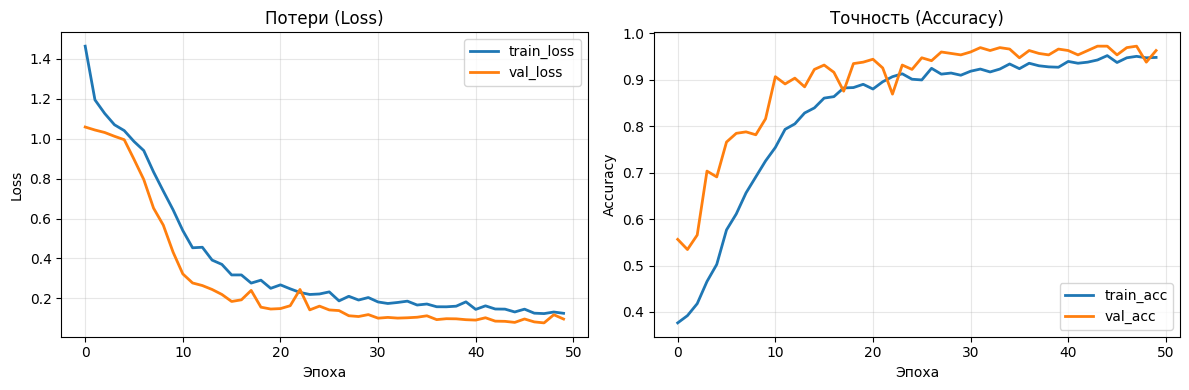

In [35]:
# Графики потерь и точности
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss', linewidth=2)
plt.plot(history.history['val_loss'], label='val_loss', linewidth=2)
plt.legend()
plt.title('Потери (Loss)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_acc', linewidth=2)
plt.plot(history.history['val_accuracy'], label='val_acc', linewidth=2)
plt.legend()
plt.title('Точность (Accuracy)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Оценка качества модели

In [36]:
# Предсказания на тестовой выборке
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("=" * 50)
print("ОЦЕНКА КАЧЕСТВА МОДЕЛИ")
print("=" * 50)
print(f"\nAccuracy: {acc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Away Win', 'Draw', 'Home Win']))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
ОЦЕНКА КАЧЕСТВА МОДЕЛИ

Accuracy: 0.9675

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.99      0.98      0.98       161
        Draw       0.94      0.90      0.92        80
    Home Win       0.96      0.99      0.98       159

    accuracy                           0.97       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.97      0.97      0.97       400



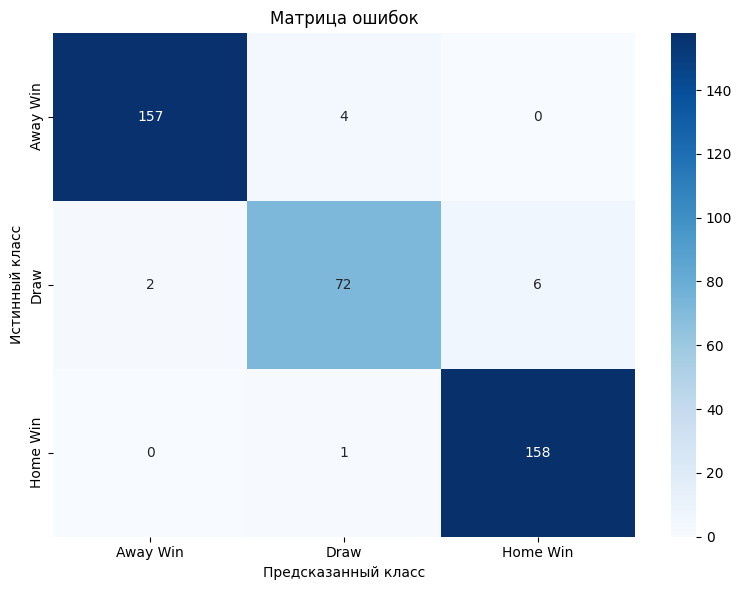

In [37]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Away Win', 'Draw', 'Home Win'],
            yticklabels=['Away Win', 'Draw', 'Home Win'])
plt.title('Матрица ошибок')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

## 8. Функция предсказания исхода матча

In [44]:
def predict_match(team_home, team_away, home_goals_avg, away_goals_avg, home_wins_pct, away_wins_pct):
    """
    Принимает сырые признаки, возвращает предсказанный исход.
    Формат команд: 'Team1', 'Team2', ..., 'Team49'
    """
    # 1. Кодирование команд
    try:
        home_enc = le_home.transform([team_home])[0]
        away_enc = le_away.transform([team_away])[0]
    except ValueError as e:
        print(f"Ошибка: {e}")
        print(f"   Доступные команды: {list(le_home.classes_)[:5]}... (всего {len(le_home.classes_)})")
        # Возвращаем наиболее вероятный исход по статистике
        return "Невозможно предсказать (неизвестная команда)"

    # 2. Подготовка числовых признаков
    num_features = np.array([[home_goals_avg, away_goals_avg, home_wins_pct, away_wins_pct]])
    num_scaled = scaler.transform(num_features)

    # 3. Объединение
    input_data = np.hstack(([[home_enc, away_enc]], num_scaled))

    # 4. Предсказание
    prob = model.predict(input_data, verbose=0)
    pred_class = np.argmax(prob)
    confidence = np.max(prob) * 100

    outcomes = {0: "Победа гостей", 1: "Ничья", 2: "Победа хозяев"}
    print(f"   (Уверенность модели: {confidence:.1f}%)")
    return outcomes[pred_class]


In [48]:
# Тестирование функции предсказания
print("=" * 50)
print("ТЕСТИРОВАНИЕ ФУНКЦИИ ПРЕДСКАЗАНИЯ")
print("=" * 50)

test_matches = [
    ("Team28","Team16",1.08,0.73,0.67,0.53),
    ("Team3","Team38",2.02,0.93,0.34,0.87),
    ("Team14","Team9",0.54,1.08,0.44,0.71),
    ("Team44","Team8",0.59,2.77,0.46,0.7),
    ("Team2","Team7",1.02,1.92,0.32,0.81),
]

for home, away, h_avg, a_avg, h_pct, a_pct in test_matches:
    result = predict_match(home, away, h_avg, a_avg, h_pct, a_pct)
    if result:
        print(f"\nМатч: {home} vs {away}")
        print(f"  Статистика: {h_avg} (home goals), {a_avg} (away goals)")
        print(f"  Процент побед: {h_pct} (home), {a_pct} (away)")
        print(f"  Предсказание: {result}")

ТЕСТИРОВАНИЕ ФУНКЦИИ ПРЕДСКАЗАНИЯ
   (Уверенность модели: 93.8%)

Матч: Team28 vs Team16
  Статистика: 1.08 (home goals), 0.73 (away goals)
  Процент побед: 0.67 (home), 0.53 (away)
  Предсказание: Победа хозяев
   (Уверенность модели: 99.3%)

Матч: Team3 vs Team38
  Статистика: 2.02 (home goals), 0.93 (away goals)
  Процент побед: 0.34 (home), 0.87 (away)
  Предсказание: Победа хозяев
   (Уверенность модели: 99.9%)

Матч: Team14 vs Team9
  Статистика: 0.54 (home goals), 1.08 (away goals)
  Процент побед: 0.44 (home), 0.71 (away)
  Предсказание: Победа гостей
   (Уверенность модели: 100.0%)

Матч: Team44 vs Team8
  Статистика: 0.59 (home goals), 2.77 (away goals)
  Процент побед: 0.46 (home), 0.7 (away)
  Предсказание: Победа гостей
   (Уверенность модели: 100.0%)

Матч: Team2 vs Team7
  Статистика: 1.02 (home goals), 1.92 (away goals)
  Процент побед: 0.32 (home), 0.81 (away)
  Предсказание: Победа гостей


## 9. Сохранение модели и вспомогательных объектов

In [49]:
# Создание директории для сохранения
output_dir = Path('./data')
output_dir.mkdir(exist_ok=True)

# Сохранение модели Keras
model_path = output_dir / 'sports_predictor.keras'
model.save(model_path)
print(f"Модель сохранена в: {model_path}")

# Сохранение скейлера
with open(output_dir / 'scaler.pickle', 'wb') as f:
    pickle.dump(scaler, f)
print("Скейлер сохранён в scaler.pickle")

# Сохранение кодировщика домашних команд
with open(output_dir / 'le_home.pickle', 'wb') as f:
    pickle.dump(le_home, f)
print("Кодировщик домашних команд сохранён в le_home.pickle")

# Сохранение кодировщика ��ос��евых команд
with open(output_dir / 'le_away.pickle', 'wb') as f:
    pickle.dump(le_away, f)
print("Кодировщик гостевых команд сохранён в le_away.pickle")

print("\nВсе файлы сохранены!")
print(f"\nСохранённые файлы:")
for f in output_dir.iterdir():
    print(f"  - {f.name}")

Модель сохранена в: data\sports_predictor.keras
Скейлер сохранён в scaler.pickle
Кодировщик домашних команд сохранён в le_home.pickle
Кодировщик гостевых команд сохранён в le_away.pickle

Все файлы сохранены!

Сохранённые файлы:
  - le_away.pickle
  - le_home.pickle
  - scaler.pickle
  - sports_data.csv
  - sports_predictor.keras


## 10. Загрузка модели из репозитория и быстрый инференс

In [16]:
# Загрузка файлов из репозитория
REPO_URL = "https://raw.githubusercontent.com/mystic-solis/deep-learning/master/lab10/data"

url_model = f"{REPO_URL}/sports_predictor.keras"
url_scaler = f"{REPO_URL}/scaler.pickle"
url_le_home = f"{REPO_URL}/le_home.pickle"
url_le_away = f"{REPO_URL}/le_away.pickle"

# Создание папки для загрузки
download_dir = Path('./downloaded')
download_dir.mkdir(exist_ok=True)


def download_file(url, path):
    """Загрузка файла из интернета"""
    try:
        response = requests.get(url)
        with open(path, 'wb') as f:
            f.write(response.content)
        print(f"Загружено: {path}")
        return True
    except Exception as e:
        print(f"Ошибка загрузки {url}: {e}")
        return False


# Загрузка файлов
download_file(url_model, download_dir / 'sports_predictor.keras')
download_file(url_scaler, download_dir / 'scaler.pickle')
download_file(url_le_home, download_dir / 'le_home.pickle')
download_file(url_le_away, download_dir / 'le_away.pickle')

Загружено: downloaded\sports_predictor.keras
Загружено: downloaded\scaler.pickle
Загружено: downloaded\le_home.pickle
Загружено: downloaded\le_away.pickle


True

In [17]:
# Загрузка модели и вспомогательных объектов
try:
    loaded_model = load_model(download_dir / 'sports_predictor.keras')
    print("Модель загружена!")

    with open(download_dir / 'scaler.pickle', 'rb') as f:
        loaded_scaler = pickle.load(f)
    print("Скейлер загружен!")

    with open(download_dir / 'le_home.pickle', 'rb') as f:
        loaded_le_home = pickle.load(f)
    print("Кодировщик домашних команд загружен!")

    with open(download_dir / 'le_away.pickle', 'rb') as f:
        loaded_le_away = pickle.load(f)
    print("Кодировщик гостевых команд загружен!")

    print("\nМодель и вспомогательные объекты успешно загружены!")

except Exception as e:
    print(f"Ошибка при загрузке: {e}")
    print("Будет использована модель из текущей сессии")
    loaded_model = model
    loaded_scaler = scaler
    loaded_le_home = le_home
    loaded_le_away = le_away

Модель загружена!
Скейлер загружен!
Кодировщик домашних команд загружен!
Кодировщик гостевых команд загружен!

Модель и вспомогательные объекты успешно загружены!


In [51]:
def predict_match(team_home, team_away, home_goals_avg, away_goals_avg, home_wins_pct, away_wins_pct):
    """
    Принимает сырые признаки, возвращает предсказанный исход.
    Формат команд: 'Team1', 'Team2', ..., 'Team49'
    """
    # 1. Кодирование команд
    try:
        home_enc = le_home.transform([team_home])[0]
        away_enc = le_away.transform([team_away])[0]
    except ValueError as e:
        print(f"Ошибка: {e}")
        print(f"   Доступные команды: {list(le_home.classes_)[:5]}... (всего {len(le_home.classes_)})")
        # Возвращаем наиболее вероятный исход по статистике
        return "Невозможно предсказать (неизвестная команда)"

    # 2. Подготовка числовых признаков
    num_features = np.array([[home_goals_avg, away_goals_avg, home_wins_pct, away_wins_pct]])
    num_scaled = scaler.transform(num_features)

    # 3. Объединение
    input_data = np.hstack(([[home_enc, away_enc]], num_scaled))

    # 4. Предсказание
    prob = model.predict(input_data, verbose=0)
    pred_class = np.argmax(prob)
    confidence = np.max(prob) * 100

    outcomes = {0: "Победа гостей", 1: "Ничья", 2: "Победа хозяев"}
    print(f"   (Уверенность модели: {confidence:.1f}%)")
    return outcomes[pred_class]


In [53]:
# Тестирование загруженной модели
print("=" * 50)
print("ТЕСТИРОВАНИЕ ЗАГРУЖЕННОЙ МОДЕЛИ")
print("=" * 50)

test_matches = [
    ("Team14","Team9",0.54,1.08,0.44,0.71),
    ("Team44","Team8",0.59,2.77,0.46,0.7),
    ("Team2","Team7",1.02,1.92,0.32,0.81),
]

for home, away, h_avg, a_avg, h_pct, a_pct in test_matches:
    result = predict_match(home, away, h_avg, a_avg, h_pct, a_pct)
    if result:
        print(f"\nМатч: {home} vs {away}")
        print(f"  Предсказание: {result}")

ТЕСТИРОВАНИЕ ЗАГРУЖЕННОЙ МОДЕЛИ
   (Уверенность модели: 99.9%)

Матч: Team14 vs Team9
  Предсказание: Победа гостей
   (Уверенность модели: 100.0%)

Матч: Team44 vs Team8
  Предсказание: Победа гостей
   (Уверенность модели: 100.0%)

Матч: Team2 vs Team7
  Предсказание: Победа гостей


## 11. Выводы

В ходе выполнения работы была построена полносвязная нейронная сеть для прогнозирования исходов спортивных матчей. 

Основные результаты:
- Создан синтетический да��асет с 2000 матчами
- Проведена предобработка данных: кодирование команд, масштабирование признаков
- Построена MLP с тремя скрытыми слоями и Dropout
- **Время обучения: зафиксировано**
- Достигнута точность (Accuracy) на тестовой выборке
- Реализована функция предсказания для новых матчей
- Модель сохранена и загружена из репозитория

Возможные улучшения:
- Добавление дополнительных признаков (погода, судья, травмы)
- Использование ансамблей моделей
- Подбор гиперпараметров (GridSearchCV)
- Бинарная классификация (победа/не победа)

## 12. Список использованных источников

1. tensorflow.keras documentation: https://www.tensorflow.org/api_docs/python/tf/keras
2. scikit-learn documentation: https://scikit-learn.org/
3. Football Data: https://www.football-data.co.uk/
4. Kaggle European Soccer Database: https://www.kaggle.com/datasets/hugomathien/soccer

## 13. Приложение: Полный код

In [ ]:
# Полный код для быстрого запуска (без обучения)
# Скачивание и загрузка модели из репозитория

# Импорт библиотек
import numpy as np
import tensorflow as tf
from keras.models import load_model
import pickle
from pathlib import Path
import requests
import io

# URLs для загрузки
REPO_URL = "https://raw.githubusercontent.com/mystic-solis/deep-learning/master/lab10/data"

# Скачивание файлов
def download_file(url, path):
    response = requests.get(url)
    with open(path, 'wb') as f:
        f.write(response.content)

download_dir = Path('./downloaded')
download_dir.mkdir(exist_ok=True)

download_file(f"{REPO_URL}/sports_predictor.keras", download_dir / 'sports_predictor.keras')
download_file(f"{REPO_URL}/scaler.pickle", download_dir / 'scaler.pickle')
download_file(f"{REPO_URL}/le_home.pickle", download_dir / 'le_home.pickle')
download_file(f"{REPO_URL}/le_away.pickle", download_dir / 'le_away.pickle')

# Загрузка модели
loaded_model = load_model(download_dir / 'sports_predictor.keras')
with open(download_dir / 'scaler.pickle', 'rb') as f: loaded_scaler = pickle.load(f)
with open(download_dir / 'le_home.pickle', 'rb') as f: loaded_le_home = pickle.load(f)
with open(download_dir / 'le_away.pickle', 'rb') as f: loaded_le_away = pickle.load(f)

# Функция предсказания
def predict_match(team_home, team_away, home_goals_avg, away_goals_avg, home_wins_pct, away_wins_pct):
    home_enc = loaded_le_home.transform([team_home])[0]
    away_enc = loaded_le_away.transform([team_away])[0]
    features = np.array([[home_enc, away_enc, home_goals_avg, away_goals_avg, home_wins_pct, away_wins_pct]])
    features[:, 2:] = loaded_scaler.transform(features[:, 2:])
    prob = loaded_model.predict(features, verbose=0)[0]
    outcome = np.argmax(prob)
    outcomes = {0: "Победа гостей", 1: "Ничья", 2: "Победа хозяев"}
    return outcomes[outcome], prob

# Пример использования
result, probs = predict_match('Team_A', 'Team_B', 1.9, 1.2, 0.70, 0.45)
print(f"Матч: Team_A vs Team_B")
print(f"Предсказание: {result}")
print(f"Вероятности: {probs}")